In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm, trange
from lib.dataset import denormalize_data
from lib.trainer import ResShiftTrainer, MocolskTrainer
from lib.functions import kernel_driven_model, calculate_accuracy_metrics, density_scatter

plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'times new roman'

# Compare accuracy metrics over the test set

In [ ]:
hr_size = 160
factor = 20
weight = 0.57 if factor == 10 else 0.50
lr_size = hr_size // factor
lst_all = {}

var_name1 = f'resshift_v1_{factor}x'
trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name1)
trainer_resshift.reload_model(model_path=f'models/{var_name1}_best.pth')
trainer_resshift.set_seed_during_diffusion(0)
trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=[10]) # drop LULC
testloader = trainer_resshift.testloader_landsat_cn20

var_name2 = f'mocolsk_v1_{factor}x'
trainer_moco = MocolskTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name2)
trainer_moco.reload_model(model_path=f'models/{var_name2}.pth')
trainer_moco.load_testset_Landsat_CN20()

In [ ]:
# determine the optimal weighting of DCF on the train set

trainset = trainer_resshift.trainset
num_train = len(trainset)
lst_true, lst_prd_kd, lst_prd_itp = np.zeros((num_train,160,160)), np.zeros((num_train,160,160)), np.zeros((num_train,160,160))
reg = LinearRegression()

for i in trange(num_train):
    lst_hr, lst_lr, lst_lr_itp, ref, ndxi, dem, _, _ = trainset.__getitem__(i)
    # denormalize data
    lst_hr, lst_lr, lst_lr_itp, ref, ndxi, dem = lst_hr.numpy().squeeze(), lst_lr.numpy().squeeze(), lst_lr_itp.numpy().squeeze(), ref.numpy(), ndxi.numpy(), dem.numpy()
    lst_hr, lst_lr, lst_lr_itp = denormalize_data(lst_hr, xmin=180, xmax=360), denormalize_data(lst_lr, xmin=180, xmax=360), denormalize_data(lst_lr_itp, xmin=180, xmax=360)
    ref, ndxi, dem = denormalize_data(ref, xmin=0, xmax=1), denormalize_data(ndxi, xmin=-1, xmax=1), denormalize_data(dem, xmin=-400, xmax=8800)

    lst_true[i], lst_prd_itp[i] = lst_hr, lst_lr_itp
    # kernel-driven model
    kernel_hr = np.concatenate([ref, ndxi, dem], axis=0)
    lst_prd_kd[i] = kernel_driven_model(reg, 'bilinear', lst_lr, kernel_hr, factor=factor)


a_all = np.arange(0.0, 1.01, 0.05)
rmse_all = np.zeros_like(a_all)
for i in trange(len(a_all)):
    lst_dcf_i = lst_prd_kd * a_all[i] + lst_prd_itp * (1 - a_all[i])
    rmse_all[i] = rmse(lst_true.flatten(), lst_dcf_i.flatten())

print(a_all[np.argmin(rmse_all)], np.min(rmse_all))

dic = {'a_all': a_all, 'rmse_all': rmse_all}
pickle.dump(dic, open(f'results/dcf_tunning_{factor}x.pkl', 'wb'))

dic = pickle.load(open(f'results/dcf_tunning_10x.pkl', 'rb'))
a_all, rmse_all = dic['a_all'], dic['rmse_all']
coeffs = np.polyfit(a_all, rmse_all, 2)
a_opt = - coeffs[1] / (2 * coeffs[0])
print(a_opt) # 0.57 for 10x and 0.50 for 20x

100%|██████████| 16036/16036 [04:46<00:00, 56.00it/s]


In [ ]:
# run all models on the test set
lst_all['true'], lst_all['pgdm'] = trainer_resshift.evaluate_after_train(testloader)
_, lst_all['mocolsk'] = trainer_moco.evaluate_after_train(testloader)

# the kernel-driven model with linear regression
testset = trainer_resshift.testset1
num = testset.__len__()
lst_prd_kd, lst_prd_itp = np.zeros((num,160,160)), np.zeros((num,160,160))
reg = LinearRegression()

for i in trange(num):
    lst_hr, lst_lr, lst_lr_itp, ref, ndxi, dem, _, _ = testset.__getitem__(i)
    lst_hr, lst_lr, lst_lr_itp, ref, ndxi, dem = lst_hr.numpy().squeeze(), lst_lr.numpy().squeeze(), lst_lr_itp.numpy().squeeze(), ref.numpy(), ndxi.numpy(), dem.numpy()
    kernel_hr = np.concatenate([ref, ndxi, dem], axis=0)
    lst_prd_kd[i] = kernel_driven_model(reg, 'bilinear', lst_lr, kernel_hr, factor=factor)
    lst_prd_itp[i] = lst_lr_itp

lst_all['kd'] = denormalize_data(lst_prd_kd, xmin=180, xmax=360)
lst_all['itp'] = denormalize_data(lst_prd_itp, xmin=180, xmax=360)
lst_all['dcf'] = lst_all['kd'] * weight + lst_all['itp'] * (1 - weight)

In [ ]:
keys = ['itp', 'kd', 'dcf', 'mocolsk', 'pgdm']
df = pd.DataFrame(columns=['Method', 'RMSE', 'Bias', 'SSIM', 'Loss_phy'])
for key in keys:
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_all['true'], lst_all[key], lr_size, factor)
    # print(f"{key}: RMSE={rmse_val:.3f}, Bias={bias_val:.3f}, SSIM={ssim_val:.3f}, Loss_phy={loss_phy:.3f}")
    df.loc[len(df), :] = [key, round(rmse_val, 3), round(bias_val, 3), round(ssim_val, 3), round(loss_phy, 3)]
df.to_csv(f'results/accuracy_metrics_landsat_cn20_{factor}x.csv', index=False)
print(df)

with open(f'results/landsat_cn20_{factor}x.pkl', 'wb') as f:
    pickle.dump(lst_all, f)

    Method   RMSE   Bias   SSIM Loss_phy
0      itp  1.691  0.015  0.874    0.368
1       kd  1.633  0.015  0.884    0.195
2      dcf  1.252  0.015  0.925    0.234
3  mocolsk  0.897 -0.009  0.954    0.047
4     pgdm  0.749  0.007  0.967    0.042


# Abalation experiments

In [ ]:
# Influence of C_base on the final accuracy
chs = [8, 16, 64]

for ch in chs:
    var_name = f'resshift_10x_ch{ch}'
    trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name)
    trainer_resshift.reload_model(model_path=f'models/{var_name}_best.pth')
    trainer_resshift.set_seed_during_diffusion(0)
    trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=[10]) # drop LULC
    testloader = trainer_resshift.testloader_landsat_cn20
    lst_true, lst_pgdm = trainer_resshift.evaluate_after_train(testloader)
    rmse_chi = rmse(lst_true.flatten(), lst_pgdm.flatten())
    print(f"Ch={ch}, RMSE={rmse_chi:.3f} K")

100%|██████████| 108/108 [00:34<00:00,  3.18it/s]


Ch=8, RMSE=0.771 K


100%|██████████| 108/108 [00:37<00:00,  2.85it/s]


Ch=16, RMSE=0.658 K


100%|██████████| 215/215 [01:25<00:00,  2.51it/s]


Ch=64, RMSE=0.574 K


In [2]:
# different hyperparameters controlling the diffusion process
for i in range(1,5):
    var_name = f'resshift_v1_10x_hyper{i}'
    trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name)
    trainer_resshift.reload_model(model_path=f'models/{var_name}_best.pth')
    trainer_resshift.set_seed_during_diffusion(0)
    trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=[10]) # drop LULC
    testloader = trainer_resshift.testloader_landsat_cn20
    lst_true, lst_pgdm = trainer_resshift.evaluate_after_train(testloader)
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_true, lst_pgdm, 16, 10)
    print(f"Hyperparameter set {i}, RMSE={rmse_val:.3f} K, SSIM={ssim_val:.3f}")

100%|██████████| 108/108 [01:36<00:00,  1.12it/s]


Hyperparameter set 1, RMSE=0.607 K, SSIM=0.974


100%|██████████| 108/108 [01:35<00:00,  1.13it/s]


Hyperparameter set 2, RMSE=0.612 K, SSIM=0.973


100%|██████████| 108/108 [07:57<00:00,  4.42s/it]


Hyperparameter set 3, RMSE=0.607 K, SSIM=0.974


100%|██████████| 108/108 [07:59<00:00,  4.44s/it]


Hyperparameter set 4, RMSE=0.669 K, SSIM=0.969


# Visualization

In [47]:
keys = ['itp', 'kd', 'dcf', 'mocolsk', 'pgdm', 'true']
rmse_each_scene, sort_index_each_scene = [], []
for factor in [10, 20]:
    lst_all = pickle.load(open(f'results/landsat_cn20_{factor}x.pkl', 'rb'))
    rmse_all = []
    for key in keys[:-1]:
        rmse_all.append(rmse(lst_all['true'].reshape(-1,160*160).swapaxes(0,1), 
                         lst_all[key].reshape(-1,160*160).swapaxes(0,1), multioutput='raw_values'))
    rmse_all = np.array(rmse_all)
    rmse_each_scene.append(rmse_all)
    sort_index_each_scene.append(np.argsort(rmse_all, axis=0))

methods = ['Bilinear', 'Kernel-driven', 'DCF', 'MoCoLSK-Net', 'PGDM']
colors = ["#CDCED0", "#EAC183", "#B0F09D", "#EDB7D8", "#ACC3EC"]
factors = ['10×', '20×']

## RMSE ascending order

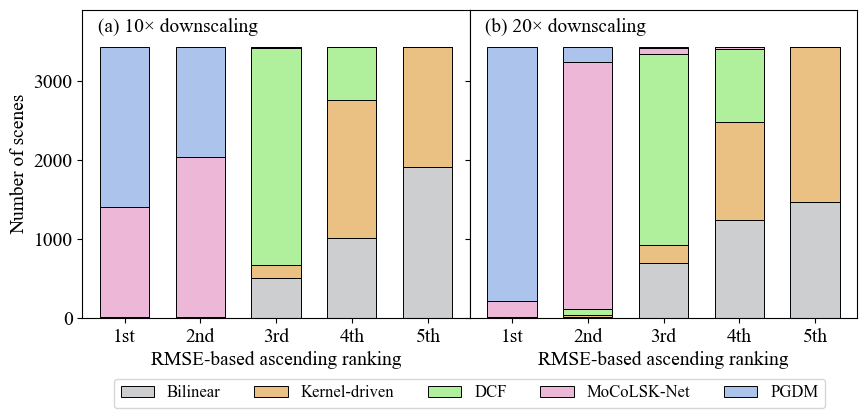

In [ ]:
num_for_ith_place = np.zeros((2,5,5), dtype=int)
for i in range(2):
    sort_idx = sort_index_each_scene[i]
    for j in range(5):
        for k in range(5):
            num_for_ith_place[i,j,k] = np.sum(sort_idx[j] == k) # count how many times each method is the best

fig, axs = plt.subplots(1, 2, figsize=(10,4))

places = ['1st', '2nd', '3rd', '4th', '5th']
for i in range(2):
    axi = axs[i]
    axi.set_ylim(0,3900)
    axi.set_xlabel('RMSE-based ascending ranking')
    axi.text(0.04, 0.93, f'({chr(97+i)}) {factors[i]} downscaling', transform=axi.transAxes, fontsize=14)
    num_for_ith_place_i = num_for_ith_place[i]
    bottom = np.zeros(5)
    for j in range(5):
        axi.bar(places, num_for_ith_place_i[:, j], width=0.65,
                bottom=bottom, color=colors[j], edgecolor='k', linewidth=0.7, label=methods[j])
        bottom += num_for_ith_place_i[:, j]

axs[0].set_ylabel('Number of scenes')
axs[1].set_yticklabels([])
plt.legend(methods, bbox_to_anchor=(-0.94, -0.17), loc='upper left',ncol=5, fontsize=12)
fig.subplots_adjust(wspace=0.)

fig.savefig(f'figs/rmse_ranking_cn20_testset.tif', dpi=300, bbox_inches='tight')

## Boxplot of RMSE

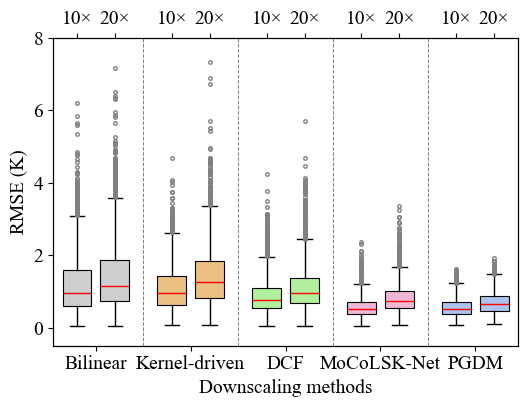

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

flierprops = dict(marker='.', markersize=5, markeredgecolor='gray')
medianprops = dict(color='r')
pos1 = np.array(range(1,6))*2.0-0.4
pos2 = np.array(range(1,6))*2.0+0.4
bp1 = ax.boxplot(rmse_each_scene[0].T, positions=pos1, widths=0.6, flierprops=flierprops, patch_artist=True, medianprops=medianprops)
bp2 = ax.boxplot(rmse_each_scene[1].T, positions=pos2, widths=0.6, flierprops=flierprops, patch_artist=True, medianprops=medianprops)

for i, box in enumerate(bp1['boxes']):
    box.set(facecolor=colors[i], edgecolor='k', linewidth=0.8)
for i, box in enumerate(bp2['boxes']):
    box.set(facecolor=colors[i], edgecolor='k', linewidth=0.8)

pos_center = (pos1 + pos2) / 2.0
ax.set_xticks(pos_center)
ax.set_xticklabels(methods)
ax.set_yticks(np.arange(0,8.1,2))
ax.set_xlabel('Downscaling methods')
ax.set_ylabel('RMSE (K)')
ax.set_ylim(-0.5,8)
ax.vlines(np.array(range(1,5))*2+1, -0.5, 8, colors='gray', linestyles='dashed', linewidth=0.7)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
pos_all = np.concatenate([pos1, pos2])
ax_top.set_xticks(pos_all, labels=np.repeat(factors, 5).tolist())

fig.savefig(f'figs/rmse_boxplot_cn20_testset.tif', dpi=300, bbox_inches='tight')

## performance of PGDM over different LULC

In [ ]:
hr_size = 160
factor = 10

var_name1 = f'resshift_v1_{factor}x'
trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name1)
trainer_resshift.reload_model(model_path=f'models/{var_name1}_best.pth')
trainer_resshift.set_seed_during_diffusion(0)
trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=[10]) # drop LULC
testloader = trainer_resshift.testloader_landsat_cn20

lst_true, lst_prd, lulc = trainer_resshift.evaluate_after_train(testloader, return_lulc=True)
# np.save('results/accuracy_lulc/lst_true.npy', lst_true.astype(np.float32))
# np.save('results/accuracy_lulc/lst_prd.npy', lst_prd.astype(np.float32))
# np.save('results/accuracy_lulc/lulc.npy', lulc.astype(np.int16))

100%|██████████| 108/108 [03:13<00:00,  1.79s/it]


In [ ]:
lulc = np.load('results/accuracy_lulc/lulc.npy')
lst_true = np.load('results/accuracy_lulc/lst_true.npy')
lst_prd = np.load('results/accuracy_lulc/lst_prd.npy')
hr_size = 160

In [ ]:
N = lst_true.shape[0]
name_classes = ['unknown', 'shrub', 'grass', 'cropland', 'urban', 'barren', 'snow', 
                'water', 'wetland', 'lichen', 'forest']
num_classes = len(name_classes)

# encoded lulc: 0: unknown, 1: Shrubs 2: Herbaceous, 3: Cropland, 4: Urban, 5: Barren, 6: Snow, 7,22: Water, 8: Wetland
# 9: Moss and lichen, 10-15: closed forest, 16-21: open forest
lulc_table = np.arange(23)
lulc_table[0] = 0
lulc_table[1] = 1
lulc_table[2] = 2
lulc_table[3] = 3
lulc_table[4] = 4
lulc_table[5] = 5
lulc_table[6] = 6
lulc_table[[7,22]] = 7
lulc_table[8] = 8
lulc_table[9] = 9
lulc_table[10:22] = 10
# lulc_table[16:22] = 11

lulc_classified = lulc_table[lulc.astype(np.int16)]
lulc_flat = lulc_classified.reshape(N, -1)
total_pixels = hr_size * hr_size
ratio = np.zeros((N, num_classes), dtype=np.float32)
for c in range(num_classes):
    ratio[:, c] = (lulc_flat == c).sum(axis=1) / total_pixels

In [ ]:
# calculate rmse for each LULC class
rmse_each_lulc_all = [[] for _ in range(num_classes)]
lststd_each_lulc_all = [[] for _ in range(num_classes)]
threshold = 0.2
for i in tqdm(range(N)):
    for c in range(num_classes):
        if ratio[i, c] > threshold:
            rmse_each_lulc_all[c].append(rmse(lst_true[i].flatten(), lst_prd[i].flatten()))
            lststd_each_lulc_all[c].append(lst_true[i].std())

rmse_each_lulc_mean = []
rmse_each_lulc_mean_highstd = []
rmse_each_lulc_mean_medstd = []
rmse_each_lulc_mean_lowstd = []
lulc_valid = []
for c in range(num_classes):
    num = len(rmse_each_lulc_all[c])
    if num > 0:
        lulc_valid.append(name_classes[c])
        idx_std = np.argsort(lststd_each_lulc_all[c])
        rmse_lulc_all_sorted = np.array(rmse_each_lulc_all[c])[idx_std]

        rmse_each_lulc_mean.append(np.mean(rmse_lulc_all_sorted))
        rmse_each_lulc_mean_lowstd.append(np.mean(rmse_lulc_all_sorted[:num//3]))
        rmse_each_lulc_mean_medstd.append(np.mean(rmse_lulc_all_sorted[num//3: 2*num//3]))
        rmse_each_lulc_mean_highstd.append(np.mean(rmse_lulc_all_sorted[2*num//3:]))

100%|██████████| 3437/3437 [00:01<00:00, 3222.41it/s]


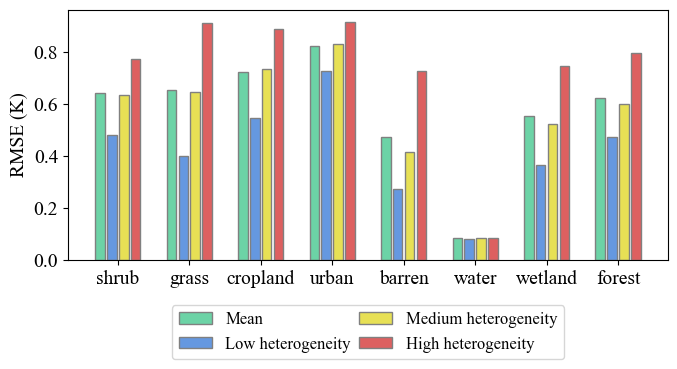

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
gap = 6
ax.bar(range(0, len(lulc_valid)*gap, gap), rmse_each_lulc_mean, label='Mean', edgecolor='gray', color="#6cd3a6")
ax.bar(range(1, len(lulc_valid)*gap+1, gap), rmse_each_lulc_mean_lowstd, label='Low heterogeneity', edgecolor='gray', color="#6598e0")
ax.bar(range(2, len(lulc_valid)*gap+2, gap), rmse_each_lulc_mean_medstd, label='Medium heterogeneity', edgecolor='gray', color="#e7e055")
ax.bar(range(3, len(lulc_valid)*gap+3, gap), rmse_each_lulc_mean_highstd, label='High heterogeneity', edgecolor='gray', color="#dd6060")

ax.set_xticks(np.arange(1.5, len(lulc_valid)*gap+1, gap))
ax.set_xticklabels(lulc_valid)
ax.legend(ncols=2, fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), columnspacing=0.5)
ax.set_ylabel('RMSE (K)')
fig.tight_layout()
plt.savefig(f'figs/rmse_each_lulc_10x_new.tif', dpi=300, bbox_inches='tight')

# Evaluate inputs' importance by dropping channels

In [ ]:
factor = 20
hr_size = 160
lr_size = hr_size // factor

var_name1 = f'resshift_v1_{factor}x'
trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name1)
trainer_resshift.reload_model(model_path=f'models/{var_name1}_best.pth')

In [ ]:
# all used
channel_schemes = [[0,1,2,3,4,5,6,7,8,10], # use DEM
                   [0,1,2,3,4,5,6,7,8,9], # use LULC
                   [0,1,2,3,4,5,9,10], # use NDXI
                   [6,7,8,9,10], # use ref
                   [0,1,2,3,4,5,6,7,8], # use DEM and LULC
                   [0,1,2,3,4,5,10], # use NDXI and DEM
                   [6,7,8,10], # use ref, DEM
                   [10], # use ref, NDXI, and DEM
                   None] # use all

lst_prd_all = []
for i in range(len(channel_schemes)):
    trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=channel_schemes[i])
    testloader = trainer_resshift.testloader_landsat_cn20
    trainer_resshift.set_seed_during_diffusion(0)
    lst_true, lst_prd_i = trainer_resshift.evaluate_after_train(dataloader=testloader)
    lst_prd_all.append(lst_prd_i)

100%|██████████| 108/108 [00:54<00:00,  1.98it/s]


In [29]:
df = pd.DataFrame(columns=['Scheme', 'RMSE', 'Bias', 'SSIM', 'Loss_phy'])
for i in tqdm(range(len(lst_prd_all))):
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_true, lst_prd_all[i], lr_size, factor)
    df.loc[len(df), :] = [i, round(rmse_val, 3), round(bias_val, 3), round(ssim_val, 3), round(loss_phy, 3)]
print(df)
df.to_csv(f'results/accuracy_metrics_guidance_schemes_{factor}x.csv', index=False)

100%|██████████| 9/9 [00:55<00:00,  6.18s/it]

  Scheme   RMSE   Bias   SSIM Loss_phy
0      0  1.402  0.023  0.903    0.055
1      1    1.6  0.019  0.878    0.051
2      2    1.3 -0.017  0.918    0.076
3      3  0.874  0.009  0.958    0.042
4      4  1.321  0.021  0.909    0.057
5      5  1.026 -0.001  0.943    0.062
6      6  0.763  0.008  0.966    0.042
7      7  0.749  0.007  0.967    0.042
8      8  0.742  0.007  0.968    0.042


# Model ensemble and estimate downscaling uncertainties

In [30]:
hr_size = 160
factor = 10
lr_size = hr_size // factor
var_name1 = f'resshift_v1_{factor}x'
trainer_resshift = ResShiftTrainer(config_base_path = 'configs/base.yaml', config_var_path = 'configs/var.yaml', var_name = var_name1)
trainer_resshift.reload_model(model_path=f'models/{var_name1}_best.pth')

In [ ]:
trainer_resshift.load_testset_Landsat_CN20(fixed_drop_channels=[10]) # drop LULC
testloader = trainer_resshift.testloader_landsat_cn20
# run n times
n = 5
lst_prd_all = []
for i in range(n):
    trainer_resshift.set_seed_during_diffusion(seed=i)
    lst_true, lst_prd_i = trainer_resshift.evaluate_after_train(dataloader=testloader)
    lst_prd_all.append(lst_prd_i)

lst_prd_all = np.array(lst_prd_all)
lst_prd_mean = np.mean(lst_prd_all, axis=0)
lst_prd_std = np.std(lst_prd_all, axis=0)
lst_prd_error = np.abs(lst_prd_mean - lst_true)

100%|██████████| 108/108 [01:42<00:00,  1.06it/s]


In [4]:
for i in range(n):
    rmse_i = rmse(lst_true.flatten(), lst_prd_all[i].flatten())
    print(rmse_i)

print(rmse(lst_true.flatten(), lst_prd_mean.flatten()))

0.6102932
0.6103791
0.61025083
0.6105932
0.61046845
0.5849068


In [40]:
abs_error = np.abs(lst_prd_mean - lst_true)
mae_scene = np.mean(abs_error, axis=(1,2))
lst_std_scene = np.std(lst_prd_mean, axis=(1,2)) # use prd value instead of true value to calculate the std
diff_std_scene = np.mean(lst_prd_std, axis=(1,2))
r_all = np.zeros((2,))
r_all[0] = pearsonr(diff_std_scene, mae_scene).statistic
r_all[1] = pearsonr(lst_std_scene, mae_scene).statistic

np.save(f'results/std_scene_{factor}x_new.npy', diff_std_scene)
np.save(f'results/lst_std_scene_{factor}x_new.npy', lst_std_scene)
np.save(f'results/mae_scene_{factor}x_new.npy', mae_scene)

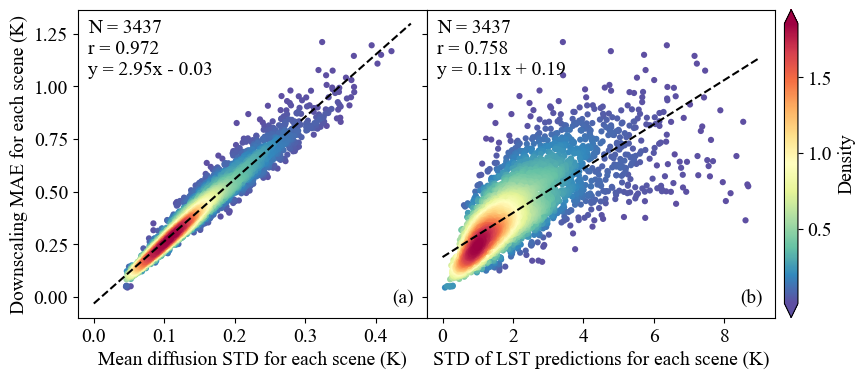

In [45]:
factor = 10
diff_std_scene = np.load(f'results/std_scene_{factor}x_new.npy')
lst_std_scene = np.load(f'results/lst_std_scene_{factor}x_new.npy')
mae_scene = np.load(f'results/mae_scene_{factor}x_new.npy')
r_all = np.zeros((2,))
r_all[0] = pearsonr(diff_std_scene, mae_scene).statistic
r_all[1] = pearsonr(lst_std_scene, mae_scene).statistic

plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Times New Roman'

fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
std_all = [diff_std_scene, lst_std_scene]
xlabel_all = ['Mean diffusion STD for each scene (K)', 'STD of LST predictions for each scene (K)']

for i in range(2):
    axi = axs[i]
    model = LinearRegression()
    model.fit(std_all[i].reshape(-1,1), mae_scene)
    k, b = model.coef_[0], model.intercept_
    if i==0:
        xx = np.linspace(0, 0.45, 100)
    else:
        xx = np.linspace(0, 9, 100)
    yy = k * xx + b
    
    if b < 0:
        text = f'N = {len(mae_scene)}\nr = {r_all[i]:.3f}\ny = {k:.2f}x - {-b:.2f}'
    else:
        text = f'N = {len(mae_scene)}\nr = {r_all[i]:.3f}\ny = {k:.2f}x + {b:.2f}'

    # density scatter
    values = np.vstack([std_all[i], mae_scene])
    kernel = stats.gaussian_kde(values)(values)
    idx = kernel.argsort()
    x_sorted, y_sorted, kernel_sorted = std_all[i][idx], mae_scene[idx], kernel[idx]
    sc = sns.scatterplot(x=x_sorted, y=y_sorted, c=kernel_sorted,
        edgecolors='none', s=20, cmap="Spectral_r", ax=axi)
    
    axi.plot(xx, yy, color='k', linewidth=1.5, linestyle='--')

    axi.text(0.03, 0.79, text, transform=axi.transAxes)
    axi.text(0.9, 0.05, f'({chr(97+i)})', transform=axi.transAxes)
    axi.set_xlabel(xlabel_all[i])

axs[0].set_ylabel('Downscaling MAE for each scene (K)')

# this may occupy the space of axs[1]
# divider = make_axes_locatable(axs[1])
# cax = divider.new_horizontal(size="4%", pad=0.1, axes_class=plt.Axes)
pos = axs[1].get_position()
fig.subplots_adjust(right=0.9, wspace=0.)
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])
fig.add_axes(cax)
fig.colorbar(sc.collections[0], cax=cax, label='Density', extend='both')

plt.savefig(f'figs/uncertainty_simulator_{factor}x.tif', dpi=300, bbox_inches='tight')